# Bethe ansatz and ED check for the open XXZ chain

This notebook compares the free-boundary Bethe-ansatz ground state with exact diagonalization for

$$
H = \sum_{i=1}^{L-1}\left(S_i^xS_{i+1}^x+S_i^yS_{i+1}^y+\Delta S_i^zS_{i+1}^z\right),
\qquad \Delta=\cos\eta,
$$

in the massless regime $-1<\Delta<1$.

The logarithmic Bethe equations are

$$
2Lp_\eta(\alpha_j)+2\phi_\eta(\alpha_j)
-\sum_{k\ne j}\left[\theta_\eta(\alpha_j-\alpha_k)
+\theta_\eta(\alpha_j+\alpha_k)\right]=2\pi I_j,
$$

with $I_j=1,\ldots,M$ for the real-root ground-state branch and
$u_j=-\eta/2+i\alpha_j/2$.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

from quante.generate.solvable.bethe_ansatz import finite_obc_xxz
from quante.generate.solvable.heisenberg import heisenberg_matrix
from quante.generate.solvable import heisenberg

L = 12
Delta = 0.7
M = L // 2

In [11]:
heisenberg.xxz_obc_finite_ground_energy(L=50, j=1, delta=1.4)

-100.32143442302655

## Ground-state roots and energy

In [12]:
state = finite_obc_xxz.solve_xxz_state(L, Delta, M=M)

print(f"converged     : {state.converged}")
print(f"residual norm : {state.residual_norm:.3e}")
print(f"Bethe numbers : {state.qnums}")
print(f"BA energy     : {state.xxz_energy(pauli=False):.15f}")

converged     : True
residual norm : 2.615e-12
Bethe numbers : [1. 2. 3. 4. 5. 6.]
BA energy     : -4.646787569828565


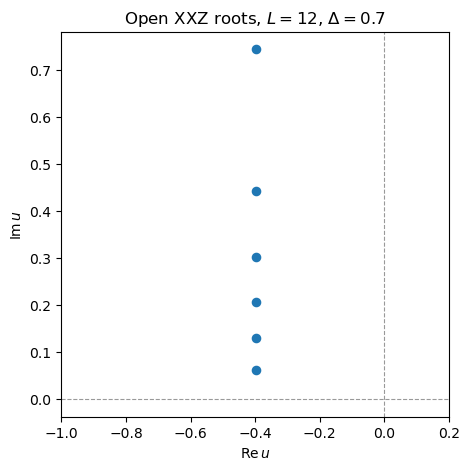

In [13]:
ax = state.plot_roots()
ax.set_title(fr"Open XXZ roots, $L={L}$, $\Delta={Delta}$")
ax.set_xlim([-1,0.2])
plt.show()

## Exact-diagonalization check

In [14]:
matrix = heisenberg_matrix(
    L,
    j=(1.0, 1.0, Delta),
    cyclic=False,
    Nup=L - M,
    pauli=False,
    sparse=True,
)
E_ed = eigsh(matrix, k=1, which="SA", return_eigenvectors=False)[0]
E_ba = state.xxz_energy(pauli=False)

print(f"ED energy : {E_ed:.15f}")
print(f"BA energy : {E_ba:.15f}")
print(f"difference: {E_ba - E_ed:.3e}")

ED energy : -4.646787569828551
BA energy : -4.646787569828565
difference: -1.332e-14


## Finite-size comparison

In [15]:
lengths = np.arange(4, 15, 2)
ba_energies = []
ed_energies = []

for length in lengths:
    length = int(length)
    n_roots = length // 2
    ba_state = finite_obc_xxz.solve_xxz_state(
        length, Delta, M=n_roots
    )
    ba_energies.append(ba_state.xxz_energy(pauli=False))

    matrix = heisenberg_matrix(
        length,
        j=(1.0, 1.0, Delta),
        cyclic=False,
        Nup=length - n_roots,
        pauli=False,
        sparse=True,
    )
    ed_energies.append(
        eigsh(matrix, k=1, which="SA", return_eigenvectors=False)[0]
    )

ba_energies = np.asarray(ba_energies)
ed_energies = np.asarray(ed_energies)
print(np.column_stack([lengths, ba_energies, ed_energies, ba_energies-ed_energies]))

[[ 4.         -1.45771535 -1.45771535 -0.        ]
 [ 6.         -2.25124081 -2.25124081  0.        ]
 [ 8.         -3.04835291 -3.04835291  0.        ]
 [10.         -3.84711829 -3.84711829  0.        ]
 [12.         -4.64678757 -4.64678757 -0.        ]
 [14.         -5.44700681 -5.44700681 -0.        ]]


## Isotropic regime: $\Delta=1$

At the XXX point the rescaled rapidities satisfy

$$
2L p(\alpha_j)-\sum_{k\ne j}\left[
\theta(\alpha_j-\alpha_k)+\theta(\alpha_j+\alpha_k)
\right]=2\pi I_j,
$$

where $p(\alpha)=2\arctan\alpha$, $\theta(\alpha)=2\arctan(\alpha/2)$, and $u=-1/2+i\alpha/2$.

In [16]:
Delta_xxx = 1.0
xxx_state = finite_obc_xxz.solve_xxz_state(L, Delta_xxx, M=M)

xxx_matrix = heisenberg_matrix(
    L,
    j=(1.0, 1.0, 1.0),
    cyclic=False,
    Nup=L - M,
    pauli=False,
    sparse=True,
)
E_xxx_ed = eigsh(
    xxx_matrix, k=1, which="SA", return_eigenvectors=False
)[0]
E_xxx_ba = xxx_state.xxz_energy(pauli=False)

print(f"converged     : {xxx_state.converged}")
print(f"residual norm : {xxx_state.residual_norm:.3e}")
print(f"rapidities    : {xxx_state.alphas}")
print(f"ED energy     : {E_xxx_ed:.15f}")
print(f"BA energy     : {E_xxx_ba:.15f}")
print(f"difference    : {E_xxx_ba-E_xxx_ed:.3e}")

converged     : True
residual norm : 6.315e-14
rapidities    : [0.15910261 0.32851441 0.52228427 0.76602758 1.1250539  1.93428004]
ED energy     : -5.142090632840532
BA energy     : -5.142090632840531
difference    : 8.882e-16


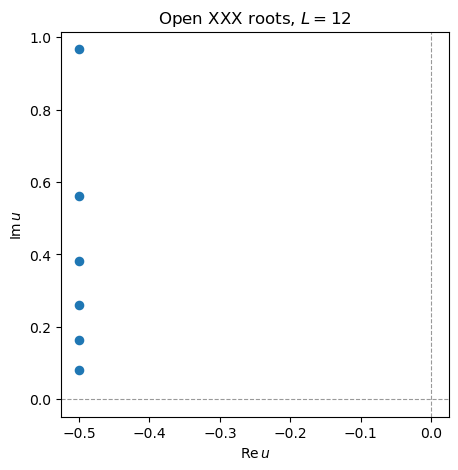

In [17]:
ax = xxx_state.plot_roots()
ax.set_title(fr"Open XXX roots, $L={L}$")
plt.show()

In [18]:
for length in range(4, 13, 2):
    n_roots = length // 2
    ba_state = finite_obc_xxz.solve_xxz_state(
        length, Delta_xxx, M=n_roots
    )
    matrix = heisenberg_matrix(
        length,
        j=(1.0, 1.0, 1.0),
        cyclic=False,
        Nup=length - n_roots,
        pauli=False,
        sparse=True,
    )
    E_ed = eigsh(
        matrix, k=1, which="SA", return_eigenvectors=False
    )[0]
    E_ba = ba_state.xxz_energy(pauli=False)
    print(length, E_ba, E_ed, E_ba-E_ed)

4 -1.6160254037844388 -1.6160254037844393 4.440892098500626e-16
6 -2.4935771338879267 -2.4935771338879262 -4.440892098500626e-16
8 -3.3749325986878906 -3.3749325986878893 -1.3322676295501878e-15
10 -4.258035207282882 -4.25803520728288 -1.7763568394002505e-15
12 -5.142090632840531 -5.142090632840538 7.105427357601002e-15


## Massive regime: $\Delta>1$

For $\Delta=\cosh\gamma>1$, the same solver switches to

$$
p_\gamma(\alpha)=2\arctan\left[\frac{\tan(\alpha/2)}{\tanh(\gamma/2)}\right],
\quad
\phi_\gamma(\alpha)=-2\arctan\left[\tanh(\gamma/2)\tan(\alpha/2)\right],
$$

$$
\theta_\gamma(\alpha)=2\arctan\left[\frac{\tan(\alpha/2)}{\tanh\gamma}\right].
$$

In [19]:
Delta_massive = 1.5
massive_state = finite_obc_xxz.solve_xxz_state(
    L, Delta_massive, M=M
)

massive_matrix = heisenberg_matrix(
    L,
    j=(1.0, 1.0, Delta_massive),
    cyclic=False,
    Nup=L - M,
    pauli=False,
    sparse=True,
)
E_massive_ed = eigsh(
    massive_matrix, k=1, which="SA", return_eigenvectors=False
)[0]
E_massive_ba = massive_state.xxz_energy(pauli=False)

print(f"converged     : {massive_state.converged}")
print(f"residual norm : {massive_state.residual_norm:.3e}")
print(f"rapidities    : {massive_state.alphas}")
print(f"ED energy     : {E_massive_ed:.15f}")
print(f"BA energy     : {E_massive_ba:.15f}")
print(f"difference    : {E_massive_ba-E_massive_ed:.3e}")

converged     : True
residual norm : 5.640e-14
rapidities    : [0.1537674  0.31765363 0.50555408 0.74325511 1.09946939 2.08101365]
ED energy     : -6.050140147710431
BA energy     : -6.050140147710430
difference    : 1.776e-15


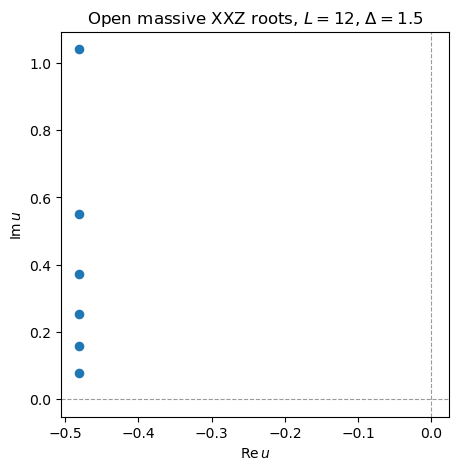

In [20]:
ax = massive_state.plot_roots()
ax.set_title(
    fr"Open massive XXZ roots, $L={L}$, $\Delta={Delta_massive}$"
)
plt.show()

In [21]:
for length in range(4, 13, 2):
    n_roots = length // 2
    ba_state = finite_obc_xxz.solve_xxz_state(
        length, Delta_massive, M=n_roots
    )
    matrix = heisenberg_matrix(
        length,
        j=(1.0, 1.0, Delta_massive),
        cyclic=False,
        Nup=length - n_roots,
        pauli=False,
        sparse=True,
    )
    E_ed = eigsh(
        matrix, k=1, which="SA", return_eigenvectors=False
    )[0]
    E_ba = ba_state.xxz_energy(pauli=False)
    print(length, E_ba, E_ed, E_ba-E_ed)

4 -1.893668395628782 -1.8936683956287812 -8.881784197001252e-16
6 -2.9273358908932483 -2.9273358908932483 0.0
8 -3.9661629346712175 -3.966162934671213 -4.440892098500626e-15
10 -5.007453912006296 -5.007453912006292 -4.440892098500626e-15
12 -6.0501401477104295 -6.050140147710422 -7.105427357601002e-15


The current implementation solves the ordinary finite real-root branch. If a root reaches the singular point $\alpha=\pi$, the solver raises an error because that state needs a singular or complex-root treatment.

## Negative isotropic and massive regimes: $\Delta\leq-1$

For an open chain, a staggered rotation gives

$$
H(\Delta)\simeq-H(-\Delta).
$$

Thus the finite-root equations reuse the $|\Delta|=1$ or $|\Delta|>1$ branch, while all mapped-state energies acquire an overall minus sign. The physical ground state for $\Delta\leq-1$ is instead the empty-root fully polarized state,

$$
E_0=(L-1)\Delta
$$

in the Pauli convention.

In [22]:
for Delta_negative in (-1.0, -1.5):
    E_ground_ba = finite_obc_xxz.ground_energy(
        L, delta=Delta_negative, pauli=False
    )
    polarized_matrix = heisenberg_matrix(
        L,
        j=(1.0, 1.0, Delta_negative),
        cyclic=False,
        Nup=L,
        pauli=False,
        sparse=False,
    )
    E_ground_ed = np.linalg.eigvalsh(polarized_matrix)[0]
    print(
        Delta_negative,
        E_ground_ba,
        E_ground_ed,
        E_ground_ba-E_ground_ed,
    )

-1.0 -2.75 -2.75 0.0
-1.5 -4.125 -4.125 0.0


A nonempty mapped Bethe state is not the physical ground state. It corresponds to the top of the same magnetization sector of $H(\Delta)$.

In [23]:
for Delta_negative in (-1.0, -1.5):
    mapped_state = finite_obc_xxz.solve_xxz_state(
        L, Delta_negative, M=M
    )
    sector_matrix = heisenberg_matrix(
        L,
        j=(1.0, 1.0, Delta_negative),
        cyclic=False,
        Nup=L-M,
        pauli=False,
        sparse=True,
    )
    E_sector_top = eigsh(
        sector_matrix, k=1, which="LA", return_eigenvectors=False
    )[0]
    E_mapped_ba = mapped_state.xxz_energy(pauli=False)
    print(
        Delta_negative,
        mapped_state.metadata["regime"],
        E_mapped_ba,
        E_sector_top,
        E_mapped_ba-E_sector_top,
    )

-1.0 isotropic_negative 5.142090632840531 5.142090632840536 -5.329070518200751e-15
-1.5 massive_negative 6.0501401477104295 6.050140147710435 -5.329070518200751e-15


## Diagonal longitudinal boundary fields

For
$$H=\sum_{i=1}^{L-1}(\sigma_i^x\sigma_{i+1}^x+\sigma_i^y\sigma_{i+1}^y+\Delta\sigma_i^z\sigma_{i+1}^z)+h_-\sigma_1^z+h_+\sigma_L^z,$$
use `DiagonalOpenXXZBoundary(h_minus, h_plus)`. The boundary object supplies the two reflection phases and the explicit energy offset $h_-+h_+$.

In [24]:
h_minus = 0.2
h_plus = -0.1
boundary = finite_obc_xxz.DiagonalOpenXXZBoundary(h_minus, h_plus)

for Delta_boundary in (-0.5, 1.0, 1.5, -1.0, -1.5):
    boundary_state = finite_obc_xxz.solve_xxz_state(
        L, Delta_boundary, M=M, boundary=boundary
    )
    hz = np.zeros(L)
    hz[0], hz[-1] = h_minus, h_plus
    boundary_matrix = heisenberg_matrix(
        L,
        j=(1.0, 1.0, Delta_boundary),
        hz=hz,
        cyclic=False,
        Nup=L-M,
        pauli=True,
        sparse=True,
    )
    which = "SA" if Delta_boundary > -1.0 else "LA"
    E_ed = eigsh(
        boundary_matrix, k=1, which=which, return_eigenvectors=False
    )[0]
    print(
        Delta_boundary,
        boundary_state.metadata["regime"],
        boundary_state.xxz_energy(pauli=True),
        E_ed,
        boundary_state.residual_norm,
    )

-0.5 massless -12.403868696919071 -12.40386869691908 1.3699846224326139e-13
1.0 isotropic -20.59204457083763 -20.592044570837626 2.1918400746395624e-14
1.5 massive -24.234737413941673 -24.23473741394167 2.0734733982992197e-14
-1.0 isotropic_negative 20.59204457083763 20.592044570837622 1.1059158862475286e-13
-1.5 massive_negative 24.234737413941687 24.23473741394165 3.44874087750852e-13


For $\Delta>-1$, the public ground-energy helper scans all magnetization sectors because boundary fields can change the ground-state magnetization.

In [25]:
for Delta_boundary in (-0.5, 1.0, 1.5):
    E_ba = heisenberg.xxz_obc_finite_ground_energy(
        L,
        delta=Delta_boundary,
        h_minus=h_minus,
        h_plus=h_plus,
        pauli=True,
    )
    hz = np.zeros(L)
    hz[0], hz[-1] = h_minus, h_plus
    full_matrix = heisenberg_matrix(
        L,
        j=(1.0, 1.0, Delta_boundary),
        hz=hz,
        cyclic=False,
        pauli=True,
        sparse=True,
    )
    E_ed = eigsh(full_matrix, k=1, which="SA", return_eigenvectors=False)[0]
    print(Delta_boundary, E_ba, E_ed, E_ba-E_ed)

-0.5 -12.403868696919071 -12.403868696919105 3.375077994860476e-14
1.0 -20.59204457083763 -20.592044570837622 -7.105427357601002e-15
1.5 -24.234737413941673 -24.234737413941687 1.4210854715202004e-14


The implementation uses ordinary real rapidities. In the massive regime it requires $|h_\pm|<\sinh\gamma$ on the mapped branch. Stronger fields produce complex boundary bound-state roots. For $\Delta\leq-1$, oppositely directed boundary fields can likewise create a domain-wall or complex-root ground state; mapped fixed-sector states remain available, but that ground-state branch is deliberately rejected.